# Fez Network: Syndrome and Ground Truth Data Generation

This notebook generates both syndrome measurements (multi-hop paths) and ground truth error rates (single-hop edges) for the quantum network.

**Outputs:**
- `measurements.pkl` - Syndrome measurements for all paths
- `graph.pkl` - Network topology graph
- `ground_truth.pkl` - Bit flip and phase flip error rates for each edge

In [15]:
from qiskit import QuantumCircuit, ClassicalRegister, transpile
import rustworkx
from rustworkx.visualization import graphviz_draw

import sys
import numpy as np
from pathlib import Path
from datetime import datetime
import pickle
import networkx as nx
from typing import List, Dict, Tuple

# Add parent directory to path for network_emulation package
sys.path.insert(0, '../..')

# Import from network_emulation package
from network_emulation import (
    # Node utilities
    Node, NODE_NAMES, NUM_NODES, INITIAL_STATES, STATE_LABELS,
    CONNECTION_TUPLES, get_node_name, route_name, get_node_id,
    # Config loading
    load_nodes_config, load_routes_config,
    # Circuit building
    build_swapping_circuit, build_multihop_swapping_circuit,
    # Experiment execution
    initialize_backend, run_provided_circuit, execute_transpiled_circuit,
    # Visualization & export
    plot_syndrome_matrix, plot_all_states_comparison, plot_state_averages_bar,
    print_matrix_summary, print_full_comparison, save_results_to_json
)

## Configuration

In [16]:
# ============================================================
# EXPERIMENT CONFIGURATION
# ============================================================

USE_REAL_HARDWARE = True  # Toggle between real hardware and simulator

# Experiment parameters
NUM_SHOTS = 4096           # Number of shots per circuit execution
OPTIMIZATION_LEVEL = 1     # Transpiler optimization (0 = no optimization)
MAX_HOPS = 3               # Maximum number of hops for path finding

# Configuration file paths
CONFIG_DIR = Path('../../configs')
CONFIG_NUM = '2'  # Configuration number to use
NODES_FILE = CONFIG_DIR / f'config_{CONFIG_NUM}_nodes.json'
ROUTES_FILE = CONFIG_DIR / f'config_{CONFIG_NUM}_routes.json'

# Input graph file
GRAPH_INPUT_FILE = Path('../../pickle_files/2x3_grid_network_graph.pkl')

# Output directory (will be created with timestamp)
OUTPUT_BASE_DIR = Path('../../pickle_files')

print("="*60)
print("EXPERIMENT CONFIGURATION")
print("="*60)
print(f"Hardware mode:      {'REAL IBM HARDWARE' if USE_REAL_HARDWARE else 'FakeFez SIMULATOR'}")
print(f"Shots per circuit:  {NUM_SHOTS}")
print(f"Optimization level: {OPTIMIZATION_LEVEL}")
print(f"Max hops:           {MAX_HOPS}")
print(f"\nConfig files:")
print(f"  Nodes:  {NODES_FILE} (exists: {NODES_FILE.exists()})")
print(f"  Routes: {ROUTES_FILE} (exists: {ROUTES_FILE.exists()})")
print(f"  Graph:  {GRAPH_INPUT_FILE} (exists: {GRAPH_INPUT_FILE.exists()})")

EXPERIMENT CONFIGURATION
Hardware mode:      REAL IBM HARDWARE
Shots per circuit:  4096
Optimization level: 1
Max hops:           3

Config files:
  Nodes:  ../../configs/config_2_nodes.json (exists: True)
  Routes: ../../configs/config_2_routes.json (exists: True)
  Graph:  ../../pickle_files/2x3_grid_network_graph.pkl (exists: True)


In [17]:
# ============================================================
# LOAD CONFIGURATIONS
# ============================================================

# Load node and route configurations from JSON files
NODES = load_nodes_config(NODES_FILE)
TRANSPORT_ROUTES = load_routes_config(ROUTES_FILE)

print("="*60)
print("LOADED CONFIGURATIONS")
print("="*60)
print(f"\nNodes ({len(NODES)} total):")
for node_id, qubits in NODES.items():
    print(f"  Node {get_node_name(node_id)}: data={qubits['data']}, "
          f"encoding={qubits['encoding']}, ancilla={qubits['ancilla']}")

print(f"\nRoutes ({len(TRANSPORT_ROUTES)} total)")
print(f"Connection pairs: {len(CONNECTION_TUPLES)}")

# ============================================================
# INITIALIZE BACKEND
# ============================================================

backend, simulator, coupling_map, IS_REAL_HARDWARE = initialize_backend(
    USE_REAL_HARDWARE,
    secrets_path='../../secrets/xiaojiekeys.json',
    simulation_method="matrix_product_state"
)

qiskit_runtime_service._discover_account:WARNING:2026-01-27 15:02:07,922: Loading account with the given token. A saved account will not be used.


LOADED CONFIGURATIONS

Nodes (6 total):
  Node A: data=[96], encoding=[83, 103], ancilla=[84, 104]
  Node B: data=[97], encoding=[87, 107], ancilla=[88, 108]
  Node C: data=[98], encoding=[91, 111], ancilla=[92, 112]
  Node D: data=[116], encoding=[101, 121], ancilla=[102, 122]
  Node E: data=[117], encoding=[105, 125], ancilla=[106, 126]
  Node F: data=[118], encoding=[109, 129], ancilla=[110, 130]

Routes (30 total)
Connection pairs: 30


qiskit_runtime_service.__init__:WARNING:2026-01-27 15:02:10,263: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-01-27 15:02:10,265: Using instance: open-instance, plan: open


Connected to REAL backend: ibm_fez
  Qubits: 156
  Status: active


## Load Network Graph

In [18]:
# ============================================================
# LOAD NETWORK GRAPH FROM PICKLE FILE
# ============================================================

with open(GRAPH_INPUT_FILE, 'rb') as f:
    loaded_graph = pickle.load(f)

print(f"Loaded graph type: {type(loaded_graph)}")
print(f"Nodes: {loaded_graph.nodes() if hasattr(loaded_graph, 'nodes') else 'N/A'}")
print(f"Edges: {list(loaded_graph.edges())}")

# Get single-hop edges for ground truth measurement
single_hop_edges = list(loaded_graph.edges())
print(f"\nSingle-hop edges for ground truth: {single_hop_edges}")

Loaded graph type: <class 'networkx.classes.graph.Graph'>
Nodes: [0, 1, 2, 3, 4, 5]
Edges: [(0, 1), (0, 3), (1, 2), (1, 4), (2, 5), (3, 4), (4, 5)]

Single-hop edges for ground truth: [(0, 1), (0, 3), (1, 2), (1, 4), (2, 5), (3, 4), (4, 5)]


Built rustworkx graph with 6 nodes and 7 edges


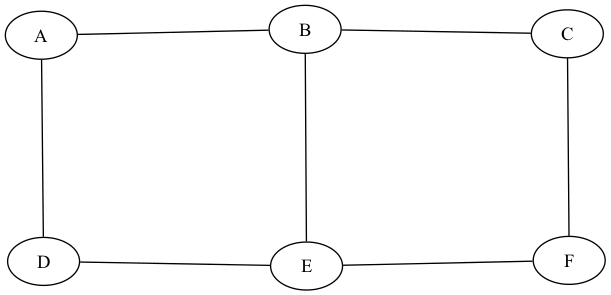

In [19]:
# ============================================================
# BUILD RUSTWORKX GRAPH FOR PATH FINDING
# ============================================================

def node_attr(node):
    return {'label': node[1]}

network_graph = rustworkx.PyGraph()
graph_node_indices = {}

for node in NODE_NAMES.items():
    id = network_graph.add_node(node)
    graph_node_indices.update({node[1]: id})

# Add edges from the loaded graph
for edge in single_hop_edges:
    u, v = edge
    # Map node IDs to rustworkx indices
    network_graph.add_edge(u, v, None)

print(f"Built rustworkx graph with {len(network_graph.node_indices())} nodes and {len(network_graph.edge_list())} edges")
graphviz_draw(network_graph, node_attr_fn=node_attr, edge_attr_fn=None, method='sfdp')

In [20]:
# ============================================================
# FIND ALL PATHS UP TO MAX_HOPS
# ============================================================

PATH_DICT = {}
total_paths = 0

for node_id in network_graph.node_indices():
    node = network_graph.get_node_data(node_id)
    paths = {id: rustworkx.all_simple_paths(network_graph, node_id, to=id, cutoff=MAX_HOPS) 
             for id in network_graph.node_indices()}
    paths.pop(node_id)
    
    for dest_id, path_list in paths.items():
        total_paths += len(path_list)
        if path_list:
            print(f"From node {node_id} to node {dest_id}: {len(path_list)} paths")
            print(f"  Paths: {path_list}")
    
    PATH_DICT.update({node_id: paths})

print(f"\nTotal paths found: {total_paths}")

From node 0 to node 1: 1 paths
  Paths: [[0, 1]]
From node 0 to node 2: 1 paths
  Paths: [[0, 1, 2]]
From node 0 to node 3: 1 paths
  Paths: [[0, 3]]
From node 0 to node 4: 2 paths
  Paths: [[0, 3, 4], [0, 1, 4]]
From node 1 to node 0: 1 paths
  Paths: [[1, 0]]
From node 1 to node 2: 1 paths
  Paths: [[1, 2]]
From node 1 to node 3: 2 paths
  Paths: [[1, 4, 3], [1, 0, 3]]
From node 1 to node 4: 1 paths
  Paths: [[1, 4]]
From node 1 to node 5: 2 paths
  Paths: [[1, 4, 5], [1, 2, 5]]
From node 2 to node 0: 1 paths
  Paths: [[2, 1, 0]]
From node 2 to node 1: 1 paths
  Paths: [[2, 1]]
From node 2 to node 4: 2 paths
  Paths: [[2, 5, 4], [2, 1, 4]]
From node 2 to node 5: 1 paths
  Paths: [[2, 5]]
From node 3 to node 0: 1 paths
  Paths: [[3, 0]]
From node 3 to node 1: 2 paths
  Paths: [[3, 4, 1], [3, 0, 1]]
From node 3 to node 4: 1 paths
  Paths: [[3, 4]]
From node 3 to node 5: 1 paths
  Paths: [[3, 4, 5]]
From node 4 to node 0: 2 paths
  Paths: [[4, 3, 0], [4, 1, 0]]
From node 4 to node 1: 1 

## Helper Functions and Classes

In [21]:
class TimeAwareMeasurement:
    """Data class for syndrome measurements with timing information."""
    def __init__(self, path_edges, histogram, duration, latency_stats=None, code_type='513'):
        """
        :param path_edges: List of tuples representing the path, e.g., [(0,1), (1,2)]
        :param histogram: A numpy array of syndrome counts.
        :param duration: The duration or average latency of this measurement (seconds).
        :param latency_stats: A dictionary with 'max', 'std', 'count'.
        :param code_type: String indicating the code type, e.g., '313_X', '313_Z', '513'.
        """
        self.path_edges = path_edges
        self.histogram = histogram
        self.duration = duration
        self.latency_stats = latency_stats
        self.code_type = code_type

In [22]:
def build_ground_truth_circuit(
    node_path: List[int],
    initial_state: str,
    nodes: Dict[int, dict],
    routes: Dict[Tuple[int, int], dict],
    num_qubits: int,
    measurement_basis: str = "Z",
) -> QuantumCircuit:
    """
    Build a circuit for ground truth measurement in X or Z basis.
    
    - Z-basis: Detects bit flips (X errors)
    - X-basis: Detects phase flips (Z errors)
    
    Args:
        node_path: Ordered list of node IDs describing the path (>=2 nodes).
        initial_state: "0" or "1"
        nodes: Dict mapping node_id -> {"data": int, "encoding": [int,int], ...}
        routes: Dict mapping (src_node,dst_node) -> {"movements": [[path1],[path2],[path3]]}
        num_qubits: Total number of physical qubits in the backend.
        measurement_basis: "X" or "Z"
    
    Returns:
        QuantumCircuit with measurement register
    """
    if len(node_path) < 2:
        raise ValueError("node_path must contain at least 2 nodes")
    if initial_state not in ("0", "1"):
        raise ValueError("initial_state must be '0' or '1'")
    if measurement_basis not in ("X", "Z"):
        raise ValueError("measurement_basis must be 'X' or 'Z'")

    start_node = node_path[0]
    final_node = node_path[-1]
    circuit = QuantumCircuit(num_qubits)

    src_data = nodes[start_node]["data"]
    dst_data = nodes[final_node]["data"]

    # Prepare initial state
    if initial_state == "1":
        circuit.x(src_data)
    
    circuit.barrier(label=f"Init: |{initial_state}⟩ @ {get_node_name(start_node)}")

    # Rotate to measurement basis BEFORE transport
    circuit.barrier(label=f"Rotate to {measurement_basis} basis")
    
    if measurement_basis == "X":
        circuit.h(src_data)

    # Transport via SWAP operations
    hopping_paths = list(zip(node_path[:-1], node_path[1:]))
    
    for i, hop in enumerate(hopping_paths):
        src_node = hop[0]
        dst_node = hop[1]

        if (src_node, dst_node) not in routes:
            raise KeyError(f"Missing route for hop {(src_node, dst_node)}")

        route = routes[(src_node, dst_node)]["movements"]
        swapping_sequence = [list(zip(path[:-1], path[1:])) for path in route 
                           if path[0] == src_data[0] and path[-1] == dst_data[0]]

        circuit.barrier(label=f"Hop {i+1}: {get_node_name(src_node)}→{get_node_name(dst_node)}")
        
        for path_swaps in swapping_sequence:
            for q1, q2 in path_swaps:
                circuit.swap(q1, q2)

    # Rotate back from measurement basis
    circuit.barrier(label=f"Rotate back from {measurement_basis} basis")
    
    if measurement_basis == "X":
        circuit.h(dst_data)

    # Measure
    circuit.barrier(label=f"Measure @ {get_node_name(final_node)}")
    
    creg = ClassicalRegister(1, name=f"meas_{measurement_basis}_{final_node}")
    circuit.add_register(creg)
    circuit.measure(dst_data, creg[0])

    return circuit

In [23]:
def calculate_flip_error_rates(
    z_basis_counts: Dict[str, int],
    x_basis_counts: Dict[str, int],
    expected_state: str = '0'
) -> Dict[str, float]:
    """
    Calculate bit flip and phase flip error rates from X and Z basis measurements.
    
    - p_bit_flip from Z-basis measurements (Z basis detects bit flips / X errors)
    - p_phase_flip from X-basis measurements (X basis detects phase flips / Z errors)
    
    Args:
        z_basis_counts: Measurement counts from Z-basis run
        x_basis_counts: Measurement counts from X-basis run  
        expected_state: Expected outcome without errors ('0' or '1')
    
    Returns:
        Dictionary with error rates:
        {
            'p_bit_flip': float,    # Bit flip probability (from Z-basis)
            'p_phase_flip': float,  # Phase flip probability (from X-basis)
            'total_shots': dict     # Shot counts for each basis
        }
    """
    
    def get_error_rate(counts: Dict[str, int], correct_label: str) -> float:
        total_shots = sum(counts.values())
        if total_shots == 0:
            return 0.0
        correct_shots = counts.get(correct_label, 0)
        return 1.0 - (correct_shots / total_shots)
    
    p_bit_flip = get_error_rate(z_basis_counts, expected_state)
    p_phase_flip = get_error_rate(x_basis_counts, expected_state)
    
    return {
        'p_bit_flip': p_bit_flip,
        'p_phase_flip': p_phase_flip,
        'total_shots': {
            'z_basis': sum(z_basis_counts.values()),
            'x_basis': sum(x_basis_counts.values())
        }
    }

## Part 1: Syndrome Measurements (Multi-hop Paths)

In [24]:
# ============================================================
# COLLECT SYNDROME MEASUREMENTS FOR ALL PATHS
# ============================================================

PATH_SYNDROME_METRICS = []

for src, all_paths in PATH_DICT.items():
    for dst, paths in all_paths.items():
        if not paths:
            continue
        print(f'\n\nCollecting syndrome data for {src} --> {dst}: ')
        
        for path in paths:
            print(f'\t{path}')
            
            # Build bit-flip syndrome circuit
            bit_circuit = build_multihop_swapping_circuit(
                node_path=path,
                initial_state='0',
                nodes=NODES,
                routes=TRANSPORT_ROUTES,
                num_qubits=backend.num_qubits,
                syndrome_type="bit"
            )
            
            # Build phase-flip syndrome circuit
            phase_circuit = build_multihop_swapping_circuit(
                node_path=path,
                initial_state='0',
                nodes=NODES,
                routes=TRANSPORT_ROUTES,
                num_qubits=backend.num_qubits,
                syndrome_type="phase"
            )

            # Execute circuits
            bit_syndrome_count = run_provided_circuit(
                circuit=bit_circuit,
                backend=backend,
                simulator=simulator,
                is_real_hardware=IS_REAL_HARDWARE,
                num_shots=NUM_SHOTS,
                optimization_level=OPTIMIZATION_LEVEL,
                return_timing=False
            )

            phase_syndrome_count = run_provided_circuit(
                circuit=phase_circuit,
                backend=backend,
                simulator=simulator,
                is_real_hardware=IS_REAL_HARDWARE,
                num_shots=NUM_SHOTS,
                optimization_level=OPTIMIZATION_LEVEL,
                return_timing=False
            )

            data = {
                'source': src,
                'dest': dst,
                'path': path,
                'bit_syn': bit_syndrome_count,
                'phase_syn': phase_syndrome_count,
                'num_shots': NUM_SHOTS,
            }
            print(f"  Bit syndrome: {bit_syndrome_count}")
            print(f"  Phase syndrome: {phase_syndrome_count}")
            PATH_SYNDROME_METRICS.append(data)

print(f"\n\nTotal syndrome measurements collected: {len(PATH_SYNDROME_METRICS)}")



	[0, 1]
Job submitted to ibm_fez: d5shjh0husoc73eps390
Job submitted to ibm_fez: d5shjoghusoc73eps3h0
  Bit syndrome: {'00': 3104, '01': 203, '10': 662, '11': 127}
  Phase syndrome: {'00': 2954, '01': 261, '10': 710, '11': 171}


	[0, 1, 2]
Job submitted to ibm_fez: d5shjq4cqoec73dijol0
Job submitted to ibm_fez: d5shjrsbmr9c739lv700
  Bit syndrome: {'00': 2716, '01': 719, '10': 389, '11': 272}
  Phase syndrome: {'00': 2561, '01': 769, '10': 462, '11': 304}


	[0, 3]
Job submitted to ibm_fez: d5shjthfodos73ek1mp0
Job submitted to ibm_fez: d5shjv8husoc73eps3qg
  Bit syndrome: {'00': 3013, '01': 634, '10': 264, '11': 185}
  Phase syndrome: {'00': 2957, '01': 649, '10': 279, '11': 211}


	[0, 3, 4]
Job submitted to ibm_fez: d5shk7kbmr9c739lv7b0
Job submitted to ibm_fez: d5shk94cqoec73dijp3g
  Bit syndrome: {'00': 2679, '01': 378, '10': 709, '11': 330}
  Phase syndrome: {'00': 2595, '01': 407, '10': 731, '11': 363}
	[0, 1, 4]
Job submitted to ibm_fez: d5shkasbmr9c739lv7gg
Job submitted to

In [25]:
# ============================================================
# FORMAT SYNDROME MEASUREMENTS
# ============================================================

formatted_measurement_data = []

for measurement in PATH_SYNDROME_METRICS:
    path = measurement['path']
    path_tuples = list(zip(path[:-1], path[1:]))
    
    bit_syndrome = list(measurement['bit_syn'].values())
    phase_syndrome = list(measurement['phase_syn'].values())
    
    bit_syndrome_measurement = TimeAwareMeasurement(
        path_edges=path_tuples,
        histogram=np.array(bit_syndrome, dtype=np.float32),
        duration=0.0,
        latency_stats={},
        code_type='313_X'
    )
    phase_syndrome_measurement = TimeAwareMeasurement(
        path_edges=path_tuples,
        histogram=np.array(phase_syndrome, dtype=np.float32),
        duration=0.0,
        latency_stats={},
        code_type='313_Z'
    )

    formatted_measurement_data.append(bit_syndrome_measurement)
    formatted_measurement_data.append(phase_syndrome_measurement)

print(f"Formatted {len(formatted_measurement_data)} syndrome measurements")

Formatted 68 syndrome measurements


## Part 2: Ground Truth Measurements (Single-hop Edges)

In [26]:
# ============================================================
# COLLECT GROUND TRUTH ERROR RATES FOR SINGLE-HOP EDGES
# ============================================================

edge_error_values = {}

print("Collecting ground truth measurements for single-hop edges...")
print(f"Edges to measure: {single_hop_edges}\n")

for edge in single_hop_edges:
    print(f"Processing edge: {edge}")
    
    # Build X-basis circuit (detects phase flips)
    circuit_x = build_ground_truth_circuit(
        node_path=edge,
        initial_state='0',
        nodes=NODES,
        routes=TRANSPORT_ROUTES,
        num_qubits=backend.num_qubits,
        measurement_basis="X"
    )
    
    # Build Z-basis circuit (detects bit flips)
    circuit_z = build_ground_truth_circuit(
        node_path=edge,
        initial_state='0',
        nodes=NODES,
        routes=TRANSPORT_ROUTES,
        num_qubits=backend.num_qubits,
        measurement_basis="Z"
    )
    
    # Transpile circuits
    transpiled_x = transpile(circuit_x, backend=backend, optimization_level=OPTIMIZATION_LEVEL)
    transpiled_z = transpile(circuit_z, backend=backend, optimization_level=OPTIMIZATION_LEVEL)

    # Execute circuits
    print("  Executing X-basis circuit...", end=' ')
    counts_x = execute_transpiled_circuit(
        transpiled_x,
        backend,
        simulator,
        num_shots=NUM_SHOTS,
        is_real_hardware=IS_REAL_HARDWARE
    )
    print(f"Done. Counts: {counts_x}")
    
    print("  Executing Z-basis circuit...", end=' ')
    counts_z = execute_transpiled_circuit(
        transpiled_z,
        backend,
        simulator,
        num_shots=NUM_SHOTS,
        is_real_hardware=IS_REAL_HARDWARE
    )
    print(f"Done. Counts: {counts_z}")
    
    # Calculate error rates
    error_rates = calculate_flip_error_rates(
        z_basis_counts=counts_z,
        x_basis_counts=counts_x,
        expected_state='0'
    )
    
    # Store as sorted edge tuple for consistency
    edge_key = tuple(sorted(edge))
    edge_error_values[edge_key] = {
        'p_bit_flip': error_rates['p_bit_flip'],
        'p_phase_flip': error_rates['p_phase_flip'],
        'z_counts': counts_z,
        'x_counts': counts_x
    }
    
    print(f"  p_bit_flip: {error_rates['p_bit_flip']:.6f}, p_phase_flip: {error_rates['p_phase_flip']:.6f}\n")

print("\n" + "="*60)
print("GROUND TRUTH SUMMARY")
print("="*60)
for edge, rates in edge_error_values.items():
    print(f"Edge {edge}: p_bit_flip={rates['p_bit_flip']:.6f}, p_phase_flip={rates['p_phase_flip']:.6f}")

Edges to measure: [(0, 1), (0, 3), (1, 2), (1, 4), (2, 5), (3, 4), (4, 5)]

Processing edge: (0, 1)
  Executing X-basis circuit... Job submitted to ibm_fez: d5shotsbmr9c739lvceg
Done. Counts: {'0': 3900, '1': 196}
  Executing Z-basis circuit... Job submitted to ibm_fez: d5shovhfodos73ek1sig
Done. Counts: {'0': 3923, '1': 173}
  p_bit_flip: 0.042236, p_phase_flip: 0.047852

Processing edge: (0, 3)
  Executing X-basis circuit... Job submitted to ibm_fez: d5shp1ccqoec73dijudg
Done. Counts: {'0': 3825, '1': 271}
  Executing Z-basis circuit... Job submitted to ibm_fez: d5shp38husoc73eps9gg
Done. Counts: {'0': 3854, '1': 242}
  p_bit_flip: 0.059082, p_phase_flip: 0.066162

Processing edge: (1, 2)
  Executing X-basis circuit... Job submitted to ibm_fez: d5shp54bmr9c739lvclg
Done. Counts: {'0': 3883, '1': 213}
  Executing Z-basis circuit... Job submitted to ibm_fez: d5shp71fodos73ek1sr0
Done. Counts: {'0': 3901, '1': 195}
  p_bit_flip: 0.047607, p_phase_flip: 0.052002

Processing edge: (1, 4)


## Save All Output Files

In [27]:
# ============================================================
# CREATE OUTPUT DIRECTORY AND SAVE ALL FILES
# ============================================================

date = datetime.today().strftime("%d-%m-%Y_%H-%M-%S")
output_path = OUTPUT_BASE_DIR / f"data_{date}"
output_path.mkdir(parents=True, exist_ok=True)

print(f"Saving outputs to: {output_path}")
print("="*60)

# -------------------------------------------------
# Save measurements.pkl (syndrome measurements)
# -------------------------------------------------
measurements_file = output_path / "measurements.pkl"
with open(measurements_file, "wb") as f:
    pickle.dump(formatted_measurement_data, f)
print(f"[OK] Saved measurements.pkl with {len(formatted_measurement_data)} samples")

# -------------------------------------------------
# Save graph.pkl (network topology)
# -------------------------------------------------
# Convert to networkx graph for compatibility
nx_graph = nx.Graph()
for edge in network_graph.edge_list():
    u, v = edge
    nx_graph.add_edge(u, v)

graph_file = output_path / "graph.pkl"
with open(graph_file, "wb") as f:
    pickle.dump(nx_graph, f)
print(f"[OK] Saved graph.pkl with {len(nx_graph.nodes)} nodes and {len(nx_graph.edges)} edges")

# -------------------------------------------------
# Save ground_truth.pkl (edge error rates)
# -------------------------------------------------
ground_truth_file = output_path / "ground_truth.pkl"
with open(ground_truth_file, "wb") as f:
    pickle.dump(edge_error_values, f)
print(f"[OK] Saved ground_truth.pkl with {len(edge_error_values)} edge error rates")

print("\n" + "="*60)
print("ALL FILES SAVED SUCCESSFULLY")
print("="*60)
print(f"\nOutput directory: {output_path}")
print(f"Files:")
print(f"  - measurements.pkl  ({len(formatted_measurement_data)} syndrome measurements)")
print(f"  - graph.pkl         ({len(nx_graph.nodes)} nodes, {len(nx_graph.edges)} edges)")
print(f"  - ground_truth.pkl  ({len(edge_error_values)} edge error rates)")

Saving outputs to: ../../pickle_files/data_27-01-2026_15-16-17
[OK] Saved measurements.pkl with 68 samples
[OK] Saved graph.pkl with 6 nodes and 7 edges
[OK] Saved ground_truth.pkl with 7 edge error rates

ALL FILES SAVED SUCCESSFULLY

Output directory: ../../pickle_files/data_27-01-2026_15-16-17
Files:
  - measurements.pkl  (68 syndrome measurements)
  - graph.pkl         (6 nodes, 7 edges)
  - ground_truth.pkl  (7 edge error rates)


In [28]:
# ============================================================
# VERIFY SAVED FILES
# ============================================================

print("Verifying saved files...\n")

# Verify measurements.pkl
with open(measurements_file, 'rb') as f:
    loaded_measurements = pickle.load(f)
print(f"measurements.pkl: {len(loaded_measurements)} measurements")
print(f"  Sample: path_edges={loaded_measurements[0].path_edges}, code_type={loaded_measurements[0].code_type}")

# Verify graph.pkl
with open(graph_file, 'rb') as f:
    loaded_graph = pickle.load(f)
print(f"\ngraph.pkl: {len(loaded_graph.nodes)} nodes, {len(loaded_graph.edges)} edges")
print(f"  Edges: {list(loaded_graph.edges())}")

# Verify ground_truth.pkl
with open(ground_truth_file, 'rb') as f:
    loaded_ground_truth = pickle.load(f)
print(f"\nground_truth.pkl: {len(loaded_ground_truth)} edges")
for edge, rates in loaded_ground_truth.items():
    print(f"  Edge {edge}: p_bit_flip={rates['p_bit_flip']:.6f}, p_phase_flip={rates['p_phase_flip']:.6f}")

Verifying saved files...

measurements.pkl: 68 measurements
  Sample: path_edges=[(0, 1)], code_type=313_X

graph.pkl: 6 nodes, 7 edges
  Edges: [(0, 1), (0, 3), (1, 2), (1, 4), (3, 4), (2, 5), (4, 5)]

ground_truth.pkl: 7 edges
  Edge (0, 1): p_bit_flip=0.042236, p_phase_flip=0.047852
  Edge (0, 3): p_bit_flip=0.059082, p_phase_flip=0.066162
  Edge (1, 2): p_bit_flip=0.047607, p_phase_flip=0.052002
  Edge (1, 4): p_bit_flip=0.045898, p_phase_flip=0.057861
  Edge (2, 5): p_bit_flip=0.055908, p_phase_flip=0.069580
  Edge (3, 4): p_bit_flip=0.078369, p_phase_flip=0.088379
  Edge (4, 5): p_bit_flip=0.067871, p_phase_flip=0.080566
